# EDA

In [126]:
import numpy as np
import pandas as pd
import pandas.api.types as ptypes
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy import stats

In [127]:
df = pd.read_csv('data/CVD_cleaned.csv')
# lowercase all columns to standardize naming
df.columns = df.columns.str.lower()
df.head()

,general_health,checkup,exercise,heart_disease,skin_cancer,other_cancer,depression,diabetes,arthritis,sex,age_category,height_(cm),weight_(kg),bmi,smoking_history,alcohol_consumption,fruit_consumption,green_vegetables_consumption,friedpotato_consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0


In [128]:
df.columns

Index(['general_health', 'checkup', 'exercise', 'heart_disease', 'skin_cancer',
       'other_cancer', 'depression', 'diabetes', 'arthritis', 'sex',
       'age_category', 'height_(cm)', 'weight_(kg)', 'bmi', 'smoking_history',
       'alcohol_consumption', 'fruit_consumption',
       'green_vegetables_consumption', 'friedpotato_consumption'],
      dtype='object')

In [129]:
# check data distribution
df.describe()

,height_(cm),weight_(kg),bmi,alcohol_consumption,fruit_consumption,green_vegetables_consumption,friedpotato_consumption
count,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000
mean,170.615249,83.588655,28.626211,5.096366,29.835200,15.110441,6.296616
std,10.658026,21.343210,6.522323,8.199763,24.875735,14.926238,8.582954
min,91.000000,24.950000,12.020000,0.000000,0.000000,0.000000,0.000000
25%,163.000000,68.040000,24.210000,0.000000,12.000000,4.000000,2.000000
50%,170.000000,81.650000,27.440000,1.000000,30.000000,12.000000,4.000000
75%,178.000000,95.250000,31.850000,6.000000,30.000000,20.000000,8.000000
max,241.000000,293.020000,99.330000,30.000000,120.000000,128.000000,128.000000


In [130]:
# check for nulls
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   general_health                308854 non-null  object 
 1   checkup                       308854 non-null  object 
 2   exercise                      308854 non-null  object 
 3   heart_disease                 308854 non-null  object 
 4   skin_cancer                   308854 non-null  object 
 5   other_cancer                  308854 non-null  object 
 6   depression                    308854 non-null  object 
 7   diabetes                      308854 non-null  object 
 8   arthritis                     308854 non-null  object 
 9   sex                           308854 non-null  object 
 10  age_category                  308854 non-null  object 
 11  height_(cm)                   308854 non-null  float64
 12  weight_(kg)                   308854 non-nul

In [131]:
df.describe(include=['O'])

,general_health,checkup,exercise,heart_disease,skin_cancer,other_cancer,depression,diabetes,arthritis,sex,age_category,smoking_history
count,308854,308854,308854,308854,308854,308854,308854,308854,308854,308854,308854,308854
unique,5,5,2,2,2,2,2,4,2,2,13,2
top,Very Good,Within the past year,Yes,No,No,No,No,No,No,Female,65-69,No
freq,110395,239371,239381,283883,278860,278976,246953,259141,207783,160196,33434,183590


# Data preprocessing
No nulls to process, focus on converting data to something that is ideal for analysis/modeling

## Categorical and binary fields
- General health
  - Convert to numerical ranking, ordinal
- Checkup
  - See if can convert to numerical years or ordinal categorical
- Yes/no fields
  - Convert to binary
- Sex
  - Convert to binary
- Age category
  - Can convert to categorical type or numerical rank

## numerical fields
- Scale remaining floating point numbers

In [132]:
# general health numerical mapping - scale from 1-5
print(df['general_health'].unique())
gen_health_num = {
    'Poor': 1,
    'Fair': 2,
    'Good': 3,
    'Very Good': 4,
    'Excellent': 5
}
df['general_health'] = df['general_health'].map(gen_health_num)

# make sure there's nothing outside of 1-5
print(df['general_health'].unique())

['Poor' 'Very Good' 'Good' 'Fair' 'Excellent']
[1 4 3 2 5]


In [133]:
# checkup
print(df['checkup'].unique())

# Define ordered categories based on their order in the list provided
checkup_categories = ['Never', '5 or more years ago', 'Within the past 5 years', 
                      'Within the past 2 years', 'Within the past year']

# Convert to categorical with ordering
df['checkup'] = pd.Categorical(df['checkup'], 
                                categories=checkup_categories, 
                                ordered=True)
print(df['checkup'].unique())

['Within the past 2 years' 'Within the past year' '5 or more years ago'
 'Within the past 5 years' 'Never']
['Within the past 2 years', 'Within the past year', '5 or more years ago', 'Within the past 5 years', 'Never']
Categories (5, object): ['Never' < '5 or more years ago' < 'Within the past 5 years' < 'Within the past 2 years' < 'Within the past year']


In [134]:
# get a list of all columns for building lists below
print(df.columns)

# Yes/no binary fields
binary_fields = ['exercise', 'heart_disease', 'skin_cancer',
                'other_cancer', 'depression',
                'arthritis', 'smoking_history']
print('\nbinary_fields\n', df[binary_fields].describe())
binary_assignments = {'Yes': 1, 'No': 0}
for binary_field in binary_fields:
    df[binary_field] = df[binary_field].map(binary_assignments)
print(df[binary_fields].describe())

# sex
print('\nSex\n', df.sex.unique())
sex_assignments = {'Female': 1, 'Male': 0}
df['sex'] = df['sex'].map(sex_assignments)
print(df.sex.unique())

# diabetes - handle as categorical ordinal
print('\ndiabetes\n', df.diabetes.unique())
diabetes_categories = ['No', 'No, pre-diabetes or borderline diabetes', 
                       'Yes, but female told only during pregnancy', 'Yes']

# Convert to categorical with ordering
df['diabetes'] = pd.Categorical(df['diabetes'], 
                                categories=diabetes_categories, 
                                ordered=True)
print(df['diabetes'].unique())

Index(['general_health', 'checkup', 'exercise', 'heart_disease', 'skin_cancer',
       'other_cancer', 'depression', 'diabetes', 'arthritis', 'sex',
       'age_category', 'height_(cm)', 'weight_(kg)', 'bmi', 'smoking_history',
       'alcohol_consumption', 'fruit_consumption',
       'green_vegetables_consumption', 'friedpotato_consumption'],
      dtype='object')

binary_fields
        exercise heart_disease skin_cancer other_cancer depression arthritis  \
count    308854        308854      308854       308854     308854    308854   
unique        2             2           2            2          2         2   
top         Yes            No          No           No         No        No   
freq     239381        283883      278860       278976     246953    207783   

       smoking_history  
count           308854  
unique               2  
top                 No  
freq            183590  
            exercise  heart_disease    skin_cancer   other_cancer  \
count  308854.000000  3088

In [135]:
# age_category
print(df['age_category'].unique())
# Convert to categorical with ordering
age_categories = ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54',
                  '55-59', '60-64', '65-69', '70-74', '75-79', '80+']
df['age_category'] = pd.Categorical(df['age_category'], 
                                    categories=age_categories, 
                                    ordered=True)
print(df['age_category'].unique())

['70-74' '60-64' '75-79' '80+' '65-69' '50-54' '45-49' '18-24' '30-34'
 '55-59' '35-39' '40-44' '25-29']
['70-74', '60-64', '75-79', '80+', '65-69', ..., '30-34', '55-59', '35-39', '40-44', '25-29']
Length: 13
Categories (13, object): ['18-24' < '25-29' < '30-34' < '35-39' ... '65-69' < '70-74' < '75-79' < '80+']


In [136]:
# check that everything looks right after conversion
df.head()

,general_health,checkup,exercise,heart_disease,skin_cancer,other_cancer,depression,diabetes,arthritis,sex,age_category,height_(cm),weight_(kg),bmi,smoking_history,alcohol_consumption,fruit_consumption,green_vegetables_consumption,friedpotato_consumption
0,1,Within the past 2 years,0,0,0,0,0,No,1,1,70-74,150.0,32.66,14.54,1,0.0,30.0,16.0,12.0
1,4,Within the past year,0,1,0,0,0,Yes,0,1,70-74,165.0,77.11,28.29,0,0.0,30.0,0.0,4.0
2,4,Within the past year,1,0,0,0,0,Yes,0,1,60-64,163.0,88.45,33.47,0,4.0,12.0,3.0,16.0
3,1,Within the past year,1,1,0,0,0,Yes,0,0,75-79,180.0,93.44,28.73,0,0.0,30.0,30.0,8.0
4,3,Within the past year,0,0,0,0,0,No,0,0,80+,191.0,88.45,24.37,1,0.0,8.0,4.0,0.0


In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype   
---  ------                        --------------   -----   
 0   general_health                308854 non-null  int64   
 1   checkup                       308854 non-null  category
 2   exercise                      308854 non-null  int64   
 3   heart_disease                 308854 non-null  int64   
 4   skin_cancer                   308854 non-null  int64   
 5   other_cancer                  308854 non-null  int64   
 6   depression                    308854 non-null  int64   
 7   diabetes                      308854 non-null  category
 8   arthritis                     308854 non-null  int64   
 9   sex                           308854 non-null  int64   
 10  age_category                  308854 non-null  category
 11  height_(cm)                   308854 non-null  float64 
 12  weight_(kg)                   

<AxesSubplot:>

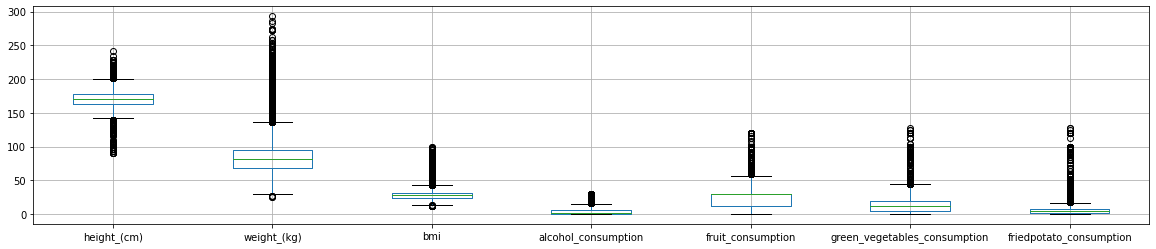

In [138]:
# TODO: add boxplots for checking outliers before scaling data
# num_cols = [col for col in df.columns if ptypes.is_numeric_dtype(df[col])]
num_cols = [col for col in df.columns if ptypes.is_numeric_dtype(df[col]) and not (ptypes.is_bool_dtype(df[col]) or df[col].dtype == 'int64')]
binary_cols = [col for col in df.columns if ptypes.is_numeric_dtype(df[col]) and df[col].dtype == 'int64']
binary_cols.remove('general_health') # 1-5, integer
binary_cols.remove('heart_disease') # target
cat_cols = [col for col in df.columns if ptypes.is_categorical_dtype(df[col])]
df.boxplot(num_cols, figsize=(20, 4))

In [139]:
# look at high weight - above 130 kg (287 pounds)
outlier_weights = df[df['weight_(kg)'] > 130]
print(f'% Outlier weight ( > 130 kg or 287 pounds): {len(outlier_weights)/ len(df) * 100:.2f}%')
outlier_weights['heart_disease'].describe()

% Outlier weight ( > 130 kg or 287 pounds): 3.09%


count    9529.000000
mean        0.097282
std         0.296357
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: heart_disease, dtype: float64

In [140]:
# TODO: make some notes about consumption outliers
# look at high fruit - above 60
fruit_outlier_weights = df[df['fruit_consumption'] > 60]
print(f'% Outlier: {len(fruit_outlier_weights)/ len(df) * 100:.2f}%')
fruit_outlier_weights['fruit_consumption'].describe()

% Outlier: 6.51%


count    20098.000000
mean        94.658573
std         10.965559
min         62.000000
25%         90.000000
50%         90.000000
75%         90.000000
max        120.000000
Name: fruit_consumption, dtype: float64

In [141]:
# look at high veg
veg_outlier_weights = df[df['green_vegetables_consumption'] > 45]
print(f'% Outlier: {len(veg_outlier_weights)/ len(df) * 100:.2f}%')
veg_outlier_weights['heart_disease'].describe()

% Outlier: 3.83%


count    11832.000000
mean         0.059584
std          0.236725
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: heart_disease, dtype: float64

In [142]:
# look at high friedpotato
potato_outlier_weights = df[df['friedpotato_consumption'] > 20]
print(f'% Outlier: {len(potato_outlier_weights)/ len(df) * 100:.2f}%')
potato_outlier_weights['heart_disease'].describe()

% Outlier: 4.03%


count    12447.000000
mean         0.088134
std          0.283501
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: heart_disease, dtype: float64

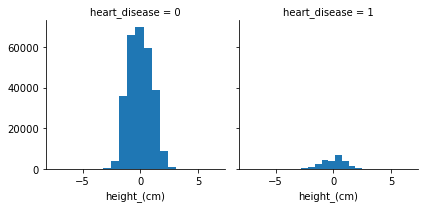

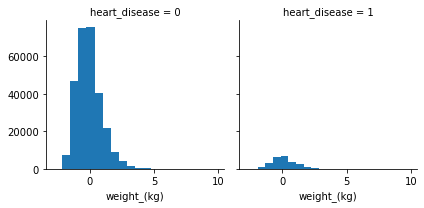

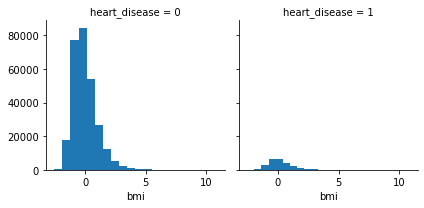

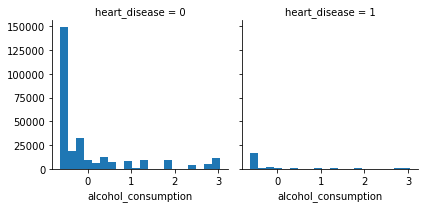

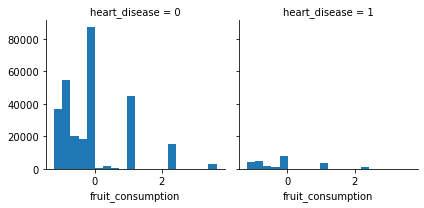

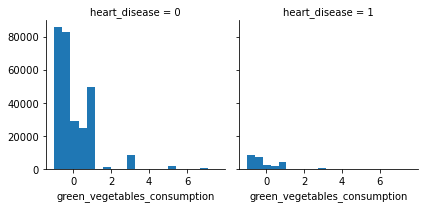

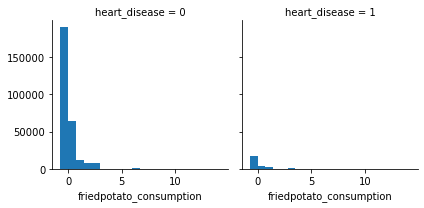

In [154]:
for col in num_cols:
    g = sns.FacetGrid(df, col='heart_disease')
    g.map(plt.hist, col, bins=20)

In [143]:
df[cat_cols].head()

,checkup,diabetes,age_category
0,Within the past 2 years,No,70-74
1,Within the past year,Yes,70-74
2,Within the past year,Yes,60-64
3,Within the past year,Yes,75-79
4,Within the past year,No,80+


In [144]:
# check binary/categorical fields in relation to heart disease target (grid)
for col in binary_cols:
    display(df[[col, 'heart_disease']].groupby(['heart_disease'], as_index=False).mean().sort_values(by='heart_disease', ascending=False))

,heart_disease,exercise
1,1,0.639422
0,0,0.786993


,heart_disease,skin_cancer
1,1,0.187818
0,0,0.089135


,heart_disease,other_cancer
1,1,0.188819
0,0,0.088639


,heart_disease,depression
1,1,0.244323
0,0,0.196560


,heart_disease,arthritis
1,1,0.570742
0,0,0.305827


,heart_disease,sex
1,1,0.396380
0,0,0.529436


,heart_disease,smoking_history
1,1,0.584037
0,0,0.389879


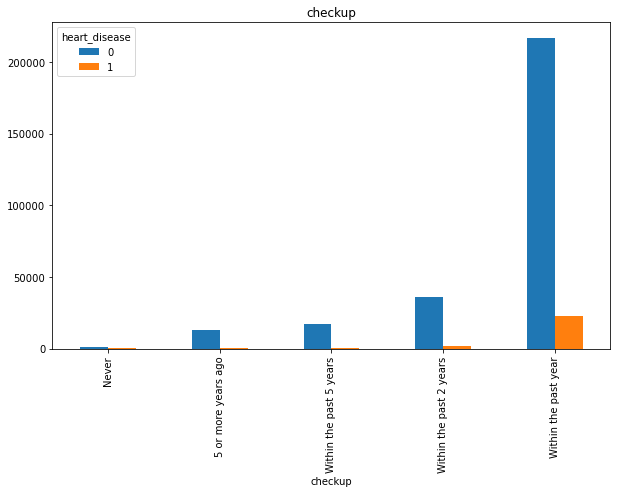

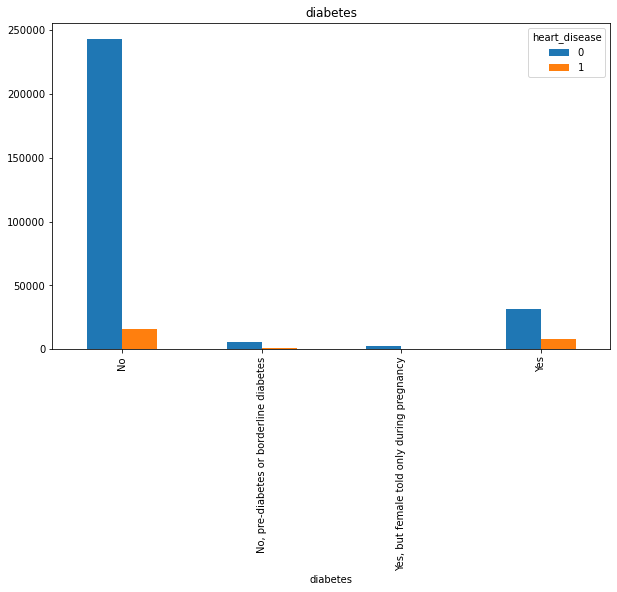

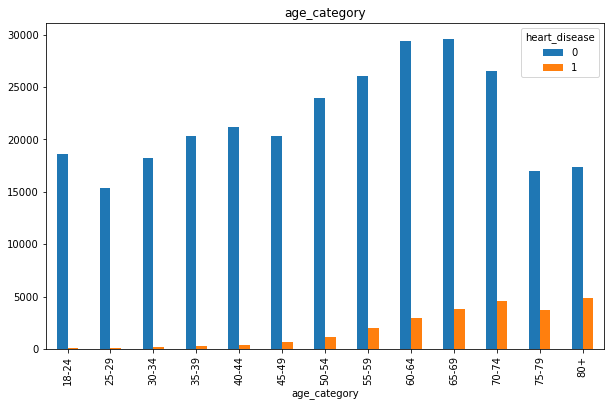

In [145]:
for col in cat_cols:
    df.groupby([col])['heart_disease'].value_counts().unstack().plot(kind='bar', figsize=(10, 6), title=f'{col}')

In [146]:
# standardize floating point numbers
float_columns = df.select_dtypes(include='float').columns.tolist()
print(float_columns)

# Fit and transform the selected float columns to standardize them
scaler = StandardScaler()
df[float_columns] = scaler.fit_transform(df[float_columns])
df[float_columns].head()

['height_(cm)', 'weight_(kg)', 'bmi', 'alcohol_consumption', 'fruit_consumption', 'green_vegetables_consumption', 'friedpotato_consumption']


,height_(cm),weight_(kg),bmi,alcohol_consumption,fruit_consumption,green_vegetables_consumption,friedpotato_consumption
0,-1.934250,-2.386180,-2.159696,-0.621527,0.006625,0.059597,0.664502
1,-0.526857,-0.303547,-0.051548,-0.621527,0.006625,-1.012342,-0.267579
2,-0.714510,0.227770,0.742649,-0.133707,-0.716973,-0.811354,1.130543
3,0.880535,0.461569,0.015913,-0.621527,0.006625,0.997544,0.198462
4,1.912623,0.227770,-0.652562,-0.621527,-0.877772,-0.744358,-0.733620


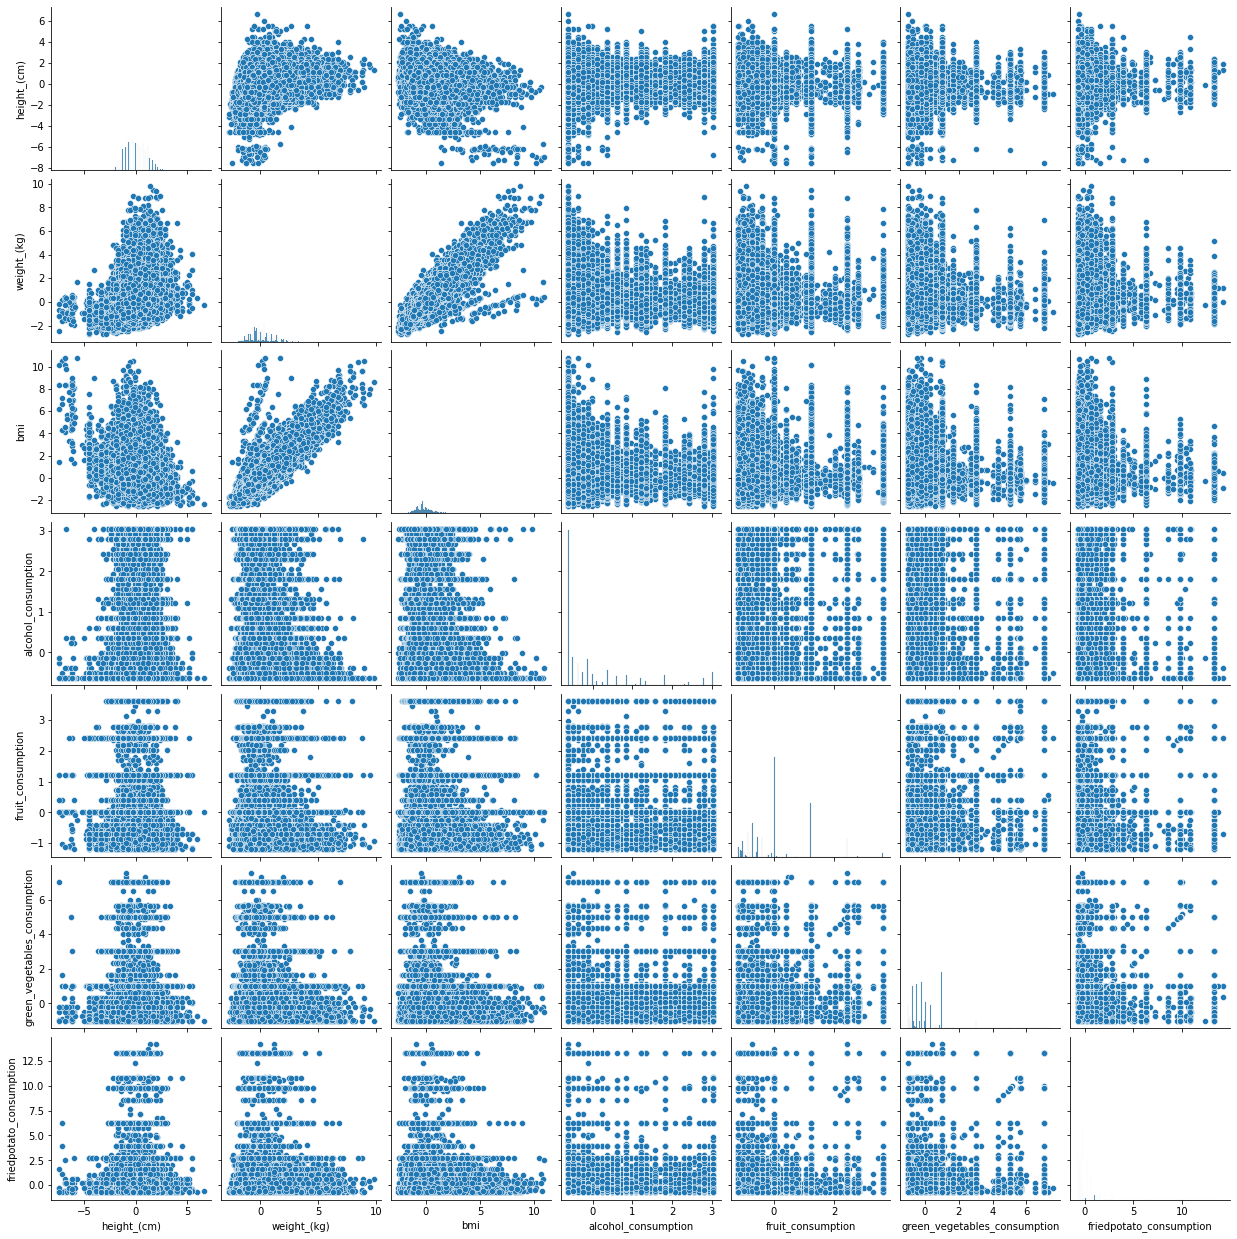

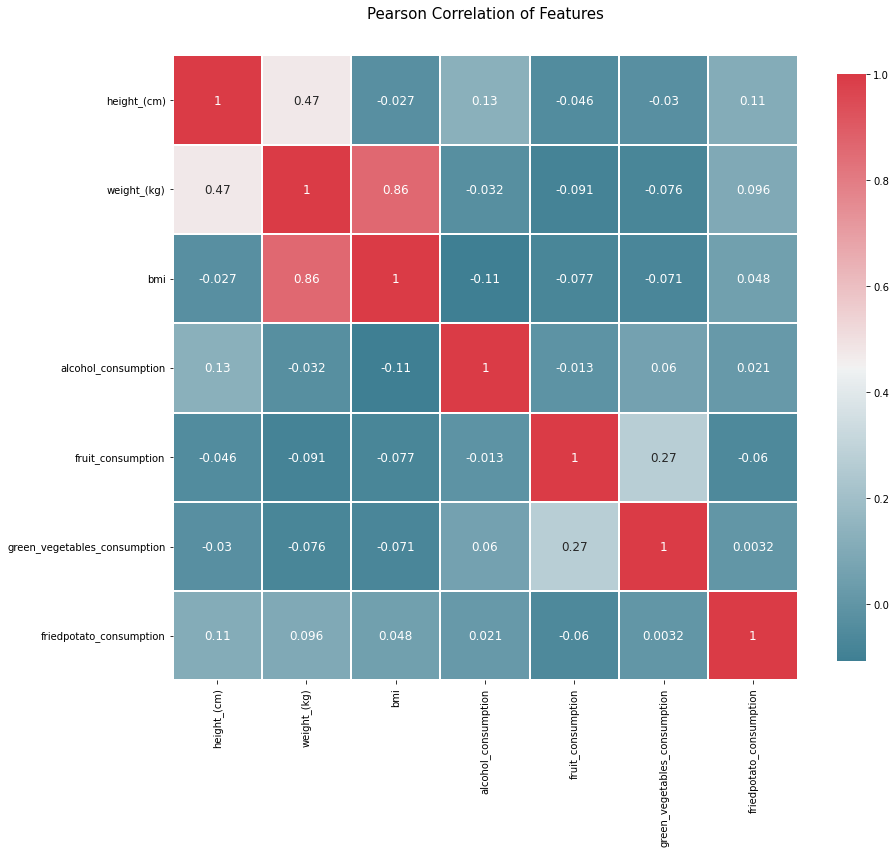

In [147]:
# note: code taken from lecture slides
# pairplot
sns.pairplot(df[float_columns])
plt.show()

# correlation heatmap
def correlation_heatmap(data):
    _ , ax = plt.subplots(figsize =(14, 12)) #Only ax is used in following code, we do not assign value to the other variable
    colormap = sns.diverging_palette(220, 10, as_cmap = True)
    
    sns.heatmap(
        data.corr(), 
        cmap = colormap,
        square=True, 
        cbar_kws={'shrink':.9 }, 
        ax=ax,
        annot=True, 
        linewidths=0.1,vmax=1.0, linecolor='white',
        annot_kws={'fontsize':12 }
    )
    
    plt.title('Pearson Correlation of Features', y=1.05, size=15)
    plt.show()

correlation_heatmap(df[float_columns])

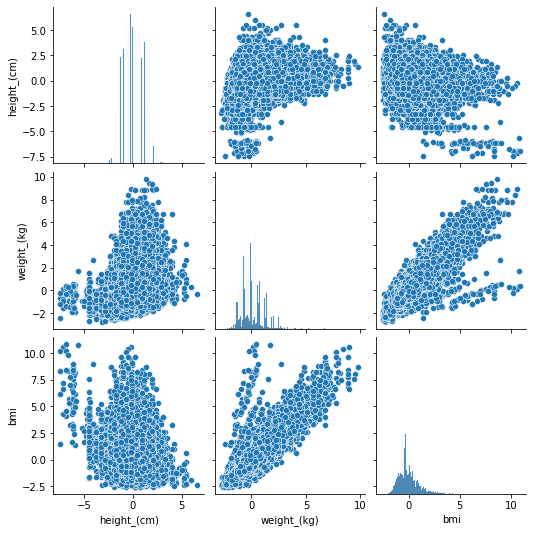

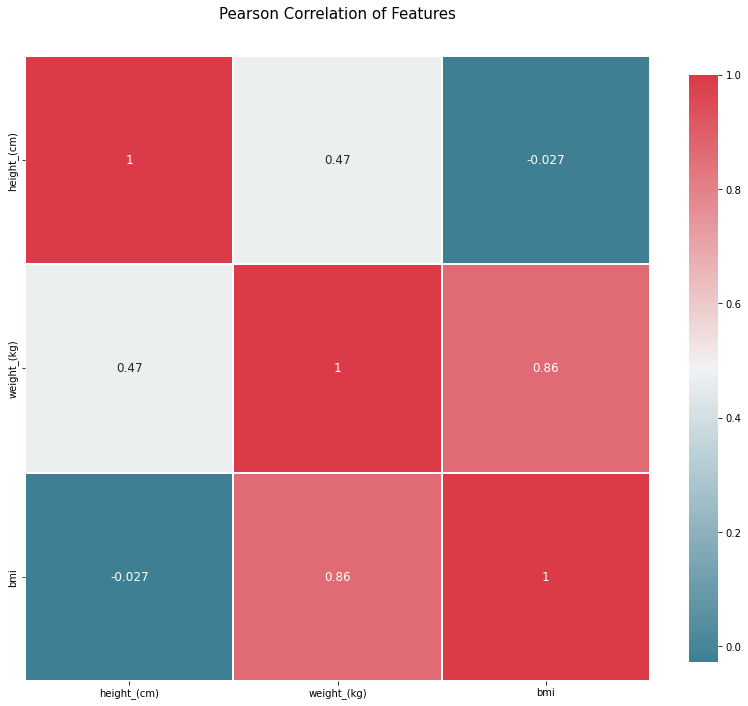

In [150]:
corr_columns = ['height_(cm)', 'weight_(kg)', 'bmi']
sns.pairplot(df[corr_columns])
plt.show()
correlation_heatmap(df[corr_columns])

# Correlation notes
- bmi & weight_(kg) have the most obvious relationship
  - May want to explore dropping one